In [2]:
# Import python libraries
#import json
import os
import pathlib
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr
import holoviews as hv

KeyboardInterrupt: 

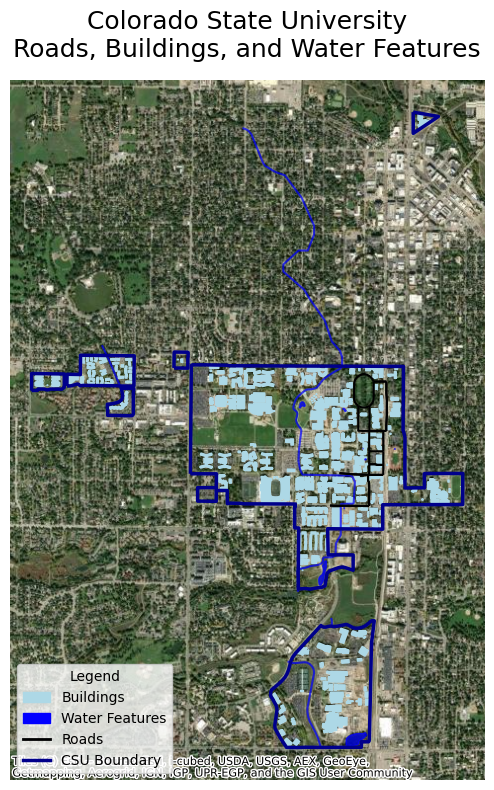

In [17]:
# Make Map of CSU
place = "Colorado State University, Colorado, USA"

boundary = ox.geocode_to_gdf(place)
polygon = boundary.geometry.iloc[0]

# Roads
G = ox.graph_from_polygon(polygon, network_type="drive")
roads = ox.graph_to_gdfs(G, nodes=False)

# Buildings
buildings = ox.features_from_polygon(
    polygon,
    tags={"building": True}
)

# Water Features
water = ox.features_from_polygon(
    polygon,
    tags={
        "natural": ["water", "wetland"],
        "waterway": True
    }
)

# Reproject
boundary = boundary.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
buildings = buildings.to_crs(epsg=3857)
water = water.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10,8))

# Buildings
buildings.plot(
    ax=ax,
    color="lightblue",
    edgecolor="lightblue",
    linewidth=1.1
)

# Water
water.plot(
    ax=ax,
    color="blue",
    edgecolor="blue",
    alpha=0.7
)

# Roads
roads.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

# Boundary
boundary.boundary.plot(
    ax=ax,
    color="darkblue",
    linewidth=2.5
)

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)
ax.set_title(
    "Colorado State University\nRoads, Buildings, and Water Features",
    fontsize=18
)

# Ledgend 

legend_elements = [
    Patch(facecolor='lightblue', edgecolor='lightblue', label='Buildings'),
    Patch(facecolor='blue', edgecolor='blue', label='Water Features'),
    Line2D([0], [0], color='black', lw=2, label='Roads'),
    Line2D([0], [0], color='darkblue', lw=2.5, label='CSU Boundary')
]

ax.legend(
    handles=legend_elements,
    title='Legend',
    loc='lower left',
    frameon=True,
    facecolor='white'
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
# CSU boundary
csu = ox.geocode_to_gdf(
    "Colorado State University, Fort Collins, Colorado, USA"
)

gdf = csu.to_crs("EPSG:4326")

<Axes: >

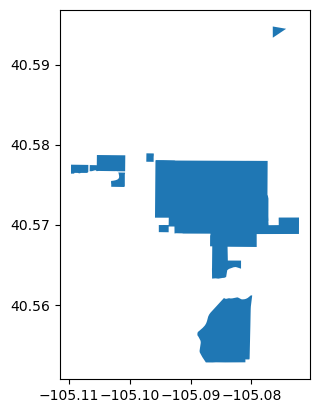

In [19]:
csu.plot()

In [1]:
%store csu

UsageError: Unknown variable 'csu'


In [35]:
%who

G	 Line2D	 Patch	 ax	 boundary	 buildings	 csu	 ctx	 eaapp	 
earthpy	 fig	 gdf	 glob	 gpd	 hv	 hvplot	 legend_elements	 os	 
ox	 pathlib	 pd	 place	 plt	 polygon	 roads	 rxr	 water	 
xr	 


In [40]:
import inspect

inspect.signature(eaapp.AppeearsDownloader)

<Signature (product, layer, start_date, end_date, polygon, recurring=False, year_range=None, download_key='appeears', project=None, interactive=True, override=False)>

In [39]:
# Download Vegiation Data
os.makedirs("./data", exist_ok=True)

ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='csu_ndvi',
    ea_dir="./data",
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="04-01",
    end_date="09-30",
    recurring=True,
    year_range=[2021, 2025],
    polygon=gdf
)

ndvi_downloader.download_files(cache=True)

TypeError: AppeearsDownloader.__init__() got an unexpected keyword argument 'ea_dir'